# Estabilizando rede neurais - Batch Normalization

### Problemas com redes profundas

In [1]:
import matplotlib.pyplot as plt
import torch
from torch import nn


def conv3x3(in_channels, out_channels):
    """Cria camada convolucional com filtro de tamanho 3 e sem bias."""
    return nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1, bias=False)

class Model(nn.Module):
    """Modelo com `num_layers` camadas convolucionais, cada uma com `num_channels` canais."""
    def __init__(self, num_layers, num_channels):
        super().__init__()
        
        layers = [
            conv3x3(1,num_channels),
            nn.ReLU()
        ]
        for _ in range(1, num_layers):
            layers.append(conv3x3(num_channels,num_channels))
            layers.append(nn.ReLU())
        self.layers = nn.ModuleList(layers)

        self.pool = nn.AdaptiveMaxPool2d(1)
        # Camada linear que recebe entrada de tamanho features e gera 10 valores de saída
        self.fc = nn.Linear(num_channels, 10)

    def forward(self, x):
        """Além de calcular o resultado, este método retorna as ativações
        inermediárias da rede."""
        acts = []
        for layer in self.layers:
            x = layer(x)
            acts.append(x)
        x = self.pool(x)
        # Transformação das imagens de tamanho bs x features x 1 x 1 para bs x features
        x = x.reshape(x.shape[0], -1)
        x = self.fc(x)

        return x, acts
    
model = Model(10, 16)
# Desabilita cálculo de gradientes, pois não será usado neste notebook
model.requires_grad_(False)
model

Model(
  (layers): ModuleList(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): ReLU()
    (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (3): ReLU()
    (4): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): ReLU()
    (6): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (7): ReLU()
    (8): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): ReLU()
    (10): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (11): ReLU()
    (12): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (13): ReLU()
    (14): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (15): ReLU()
    (16): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (17): ReLU()
    (18): Conv2d(16, 16, kernel_siz

Execute a célula abaixo diversas vezes com ctrl+enter. A saída da rede é sempre a mesma!

In [20]:
x = torch.rand(1, 1, 28, 28)
y, acts = model(x)

print(x[0,0,0])
print(y)

tensor([0.2221, 0.1583, 0.6119, 0.0624, 0.2677, 0.7368, 0.1420, 0.9567, 0.2731,
        0.7456, 0.7017, 0.1073, 0.4290, 0.6585, 0.0776, 0.7123, 0.9198, 0.4803,
        0.4833, 0.2527, 0.2711, 0.6285, 0.6315, 0.1867, 0.4120, 0.7650, 0.5319,
        0.3155])
tensor([[-0.1991, -0.1041,  0.1510, -0.1954, -0.2481, -0.2483,  0.1686,  0.1828,
         -0.0968,  0.1612]])


A saída da rede é dada apenas pelo bias da última camada:

In [21]:
print(y)
print(model.fc.bias)

tensor([[-0.1991, -0.1041,  0.1510, -0.1954, -0.2481, -0.2483,  0.1686,  0.1828,
         -0.0968,  0.1612]])
Parameter containing:
tensor([-0.1991, -0.1041,  0.1510, -0.1954, -0.2481, -0.2483,  0.1686,  0.1828,
        -0.0967,  0.1612])


Plotando a média e desvio padrão das ativações intermediárias da rede, vemos que os valores caem para zero:

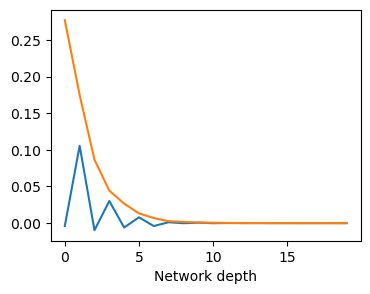

In [22]:
def show_activations(acts):
    act_mean = []
    act_std = []
    for act in acts:
        act = act.detach()
        act_mean.append(act.mean())
        act_std.append(act.std())

    plt.plot(act_mean)
    plt.plot(act_std)
    plt.xlabel("Network depth")

show_activations(acts)

Essencialmente, a operação que uma rede neural faz é dada por:

In [5]:
# Batch de dados
x = torch.rand(10)
# Parâmetros das camadas
weight = 2.
bias = 2.
# 100 camadas
for _ in range(100):
    x = weight*x+bias
print(x)

tensor([3.5148e+30, 2.7509e+30, 2.6385e+30, 3.4780e+30, 3.4049e+30, 2.7639e+30,
        3.1180e+30, 2.6267e+30, 2.6245e+30, 3.2265e+30])


Tente achar valores de `weight` e `bias` que não levem o valor de x acima a 0, infinito ou algum valor trivial.

### Batch Normalization

Ao normalizarmos os valores, as ativações se tornam bem comportadas!

In [23]:
def normalization(x):
    mean = x.mean()
    std = x.std()
    return (x-mean)/std

x = torch.rand(10)
weight = 20.
bias = -10.
for _ in range(10):
    x = weight*x+bias
    x = normalization(x)
print(x)

tensor([-0.7131, -0.1610,  1.1695,  0.3635,  0.0578, -1.5361,  1.1414, -0.8151,
         1.3677, -0.8745])


Mas e se a escala dos valores for relevante para a classificação? Por exemplo, talvez um filtro tenda a gerar valores em torno de 10, enquanto que outro filtro gere valores em torno de 0.1. Essa informação será perdida após a normalização.

Uma camada batchnorm permite reescalar os valores caso seja necessário. Os parâmetros de escala são aprendidos durante o treinamento.

In [7]:
class BatchNorm(nn.Module):
    def __init__(self):
        super().__init__()
        # nn.Parameter define um tensor com requires_grad=True e que é registrado 
        # como parâmetro treinável do modelo
        self.weight = nn.Parameter(torch.tensor(1.))
        self.bias = nn.Parameter(torch.tensor(0.))

        self.eps = 1e-5

    def forward(self, x):

        mean = x.mean()
        var = x.var()   # Variância
        # eps evita divisão por 0
        x_norm = (x-mean)/torch.sqrt(var+self.eps)

        # Reescala os valores
        y = self.weight*x_norm + self.bias

        return y
    
bn = BatchNorm()
bn(100*torch.rand(10))


tensor([ 0.3726,  0.1112,  0.6059, -0.3419,  0.9450,  0.2582,  0.4992, -2.0018,
        -1.4587,  1.0103], grad_fn=<AddBackward0>)

Mas temos um problema. E quando formos aplicar a rede após o treinamento em uma única imagem? Cada camada terá apenas uma única ativação, o que pode ser um problema. Para evitar isso, durante o treinamento podemos armazenar a média e desvio padrão de todos os batches, e usar a estimativa desses parâmetros de todos os batches para normalizar os valores ao aplicar em uma única imagem.

### Desvendando a camada BatchNorm do Pytorch

In [8]:
# Batchnorm aplicado em 3 canais
bn = nn.BatchNorm2d(3)
print(bn.weight)
print(bn.bias)

Parameter containing:
tensor([1., 1., 1.], requires_grad=True)
Parameter containing:
tensor([0., 0., 0.], requires_grad=True)


A longo de vários batches, a camada estima a média e variância dos dados:

In [9]:
# Cria batches artificiais possuindo 4 imagens cada. Cada imagem possui 3 canais
# e tamanho 256x256. Os valores das imagens são aleatórios com média 10 e
# desvio padrão 2
bs = 4
img_shape = (3, 256, 256)
batches = []
for _ in range(100):
    batch = torch.normal(mean=10, std=2, size=(bs,*img_shape))
    batches.append(batch)

for batch in batches:
    _ = bn(batch)
    print("mean", bn.running_mean, "var", bn.running_var)



mean tensor([0.9997, 0.9997, 0.9997]) var tensor([1.3015, 1.2976, 1.2995])
mean tensor([1.9001, 1.8995, 1.8995]) var tensor([1.5709, 1.5687, 1.5695])
mean tensor([2.7105, 2.7094, 2.7099]) var tensor([1.8129, 1.8124, 1.8136])
mean tensor([3.4390, 3.4385, 3.4388]) var tensor([2.0314, 2.0298, 2.0326])
mean tensor([4.0952, 4.0947, 4.0943]) var tensor([2.2279, 2.2254, 2.2291])
mean tensor([4.6852, 4.6848, 4.6846]) var tensor([2.4052, 2.4007, 2.4074])
mean tensor([5.2167, 5.2167, 5.2162]) var tensor([2.5655, 2.5624, 2.5656])
mean tensor([5.6951, 5.6957, 5.6947]) var tensor([2.7085, 2.7047, 2.7089])
mean tensor([6.1256, 6.1261, 6.1252]) var tensor([2.8388, 2.8326, 2.8371])
mean tensor([6.5126, 6.5141, 6.5127]) var tensor([2.9540, 2.9495, 2.9532])
mean tensor([6.8609, 6.8629, 6.8614]) var tensor([3.0567, 3.0537, 3.0564])
mean tensor([7.1745, 7.1767, 7.1754]) var tensor([3.1507, 3.1481, 3.1485])
mean tensor([7.4572, 7.4595, 7.4577]) var tensor([3.2346, 3.2326, 3.2332])
mean tensor([7.7115, 7.71

Os valores de `running_mean` e `running_var` são utilizados para normalizar os dados. 

No modo eval, a média estimada é usada quando a camada for aplicada em novos dados:

In [10]:
# Imagem com média 15 e desvio padrão 2
x = torch.normal(mean=15, std=2, size=(1,3,256,256))
bn.eval()
y = bn(x)
# A média do resultado deve ser aproximadamente (15-bn.running_mean)/bn.running_var**0.5
print(y.mean())

tensor(2.5010, grad_fn=<MeanBackward0>)


Retornando o batchnorm para o modo .train faz com que a camada volte a normalizar pela média e desvio do batch:

In [11]:
bn.train()
y = bn(x)
print(y.mean())

tensor(6.5658e-08, grad_fn=<MeanBackward0>)
